# Broad-line width — FWHM + line dispersion (Peterson+04 / MAHA)

Interactive verification twin of `measure_linewidth.py` — **keep the two in
sync** (the function cell below is a verbatim copy of the CLI's core block).

Input: rms spectrum or narrow-subtracted mean spectrum (e.g. the
`.subnarrow` output of `subtract_narrow_mean.py`), rest-frame,
columns `wave flux [err]`.

Method:
* profile $P(\lambda)$ = flux above a linear continuum between two line-free windows
* **FWHM** (Peterson et al. 2004, ApJ 613, 682, Sec. 3.1): on each side, mean of
  (i) first crossing of half max searching from the window edge inward and
  (ii) first drop below half max searching from the peak outward;
  double-peaked profiles (`SPLIT` set): blue side uses the blue peak, red side the red peak
* **line dispersion** (Peterson+04 eqs. 4–5):
  $\lambda_0 = \int \lambda P d\lambda / \int P d\lambda$,
  $\sigma^2_{\rm line} = \int \lambda^2 P d\lambda / \int P d\lambda - \lambda_0^2$
  (note: MAHA II eq. 7 prints $\int P\lambda d\lambda$ in the denominator — dimensional typo, Peterson form used)
* **errors** (MAHA bootstrap): from the $N$ pixels draw $N$ with replacement →
  unique subset (~63%), redo continuum + widths, `NBOOT` times; **median** = value, **std** = error
* instrumental broadening `LSF_KMS` removed in quadrature (MAHA: 925 km/s)


In [1]:
# ---------------- config: EDIT HERE ----------------
SPEC = '/Users/kaiwenzhang/Desktop/NGC 3227/NGC3227/combined.txt.meanrms.subnarrow'  # wave flux [err], rest-frame

LINE_WIN = (4800.0, 4950.0)     # line window (profile extent)
CONTI_LEFT = (4770.0, 4790.0)   # line-free continuum windows;
CONTI_RIGHT = (5060.0, 5080.0)  # set both to None -> continuum = 0
SPLIT = None                    # double-peaked: wavelength between the two
                                # peaks (e.g. 4861.0); None = single-peaked
LSF_KMS = 925.0                 # instrumental broadening, quadrature;
                                # 0 = off (MAHA average LSF: 925 km/s)
NBOOT = 500                     # bootstrap realizations
SEED = 42
KEEP_DUPLICATES = False         # False = unique subset (MAHA III 'subset')
OBJ = 'object'                  # output name tag

P = {'line_win': LINE_WIN, 'conti_left': CONTI_LEFT,
     'conti_right': CONTI_RIGHT, 'split': SPLIT}


In [2]:
# ---------------- shared core (verbatim from measure_linewidth.py) ----------------
import numpy as np

UNIT = 1.0e-14
C_KMS = 299792.458

# Okabe-Ito colorblind-safe palette, fixed assignment
C_DATA = '#000000'       # observed spectrum
C_MODEL = '#E69F00'      # half-max construction
C_BROAD = '#0072B2'      # FWHM
C_NARROW = '#009E73'     # sigma_line
C_SUB = '#D55E00'        # line profile P(lambda)
C_CON = '#CC79A7'        # continuum / background lines


def read_spec(filename):
    data = np.loadtxt(filename)
    if data.ndim != 2 or data.shape[1] < 2:
        raise ValueError('need at least 2 columns: wave flux [err]')
    err = data[:, 2] if data.shape[1] > 2 else np.zeros(data.shape[0])
    return data[:, 0], data[:, 1], err


def window_median(wave, flux, lim1, lim2):
    """Median flux and mean wavelength inside [lim1, lim2]."""
    idx = np.where((wave >= lim1) & (wave <= lim2))[0]
    if idx.size == 0:
        raise ValueError('empty window %.1f-%.1f' % (lim1, lim2))
    return np.median(flux[idx]), np.mean(wave[idx])


def linear_through(w1, f1, w2, f2, wave):
    return f1 + (f2 - f1) / (w2 - w1) * (wave - w1)


def continuum_model(wave, flux, p):
    """Linear continuum through the two window medians; zero if no windows."""
    if p.get('conti_left') is None or p.get('conti_right') is None:
        return np.zeros_like(wave)
    fl, wl = window_median(wave, flux, *p['conti_left'])
    fr, wr = window_median(wave, flux, *p['conti_right'])
    return linear_through(wl, fl, wr, fr, wave)


def _interp_cross(w1, p1, w2, p2, half):
    """Wavelength where the segment (w1,p1)-(w2,p2) crosses `half`."""
    if p2 == p1:
        return 0.5 * (w1 + w2)
    return w1 + (half - p1) * (w2 - w1) / (p2 - p1)


def _half_wavelength(w, p, ipk, half, side):
    """Peterson+04 half-max wavelength on one side of the peak at ipk.

    Two scans: (a) from the window edge inward, first crossing above
    `half`; (b) from the peak outward, first drop below `half`.
    Returns (mean of the two crossings, hit_boundary flag).
    """
    n = w.size
    boundary = False

    if side == 'blue':
        edge_range = range(0, ipk + 1)            # edge -> peak
        out_range = range(ipk, -1, -1)            # peak -> edge
        edge_i = 0
    else:
        edge_range = range(n - 1, ipk - 1, -1)
        out_range = range(ipk, n)
        edge_i = n - 1

    # scan (a): from the edge inward, first point at/above half
    lam_a = w[edge_i]
    found = False
    prev = edge_i
    for i in edge_range:
        if p[i] >= half:
            if i == edge_i:
                boundary = True
                lam_a = w[edge_i]
            else:
                lam_a = _interp_cross(w[prev], p[prev], w[i], p[i], half)
            found = True
            break
        prev = i
    if not found:                                  # never reaches half
        return np.nan, True

    # scan (b): from the peak outward, first point below half
    lam_b = w[edge_i]
    hit = False
    prev = ipk
    for i in out_range:
        if p[i] < half:
            lam_b = _interp_cross(w[prev], p[prev], w[i], p[i], half)
            hit = True
            break
        prev = i
    if not hit:                                    # still above half at edge
        boundary = True
        lam_b = w[edge_i]

    return 0.5 * (lam_a + lam_b), boundary


def measure_fwhm(w, p, split=None):
    """FWHM of profile p(w) inside the (already sliced) line window.

    split: wavelength separating blue/red peaks for double-peaked
    profiles (Peterson+04: each side measured against its own peak);
    None = single-peaked.
    Returns dict: fwhm, lam_blue, lam_red, peaks, boundary flag.
    """
    if split is None:
        ipk = int(np.argmax(p))
        ipk_b = ipk_r = ipk
    else:
        blue = np.where(w < split)[0]
        red = np.where(w >= split)[0]
        if blue.size == 0 or red.size == 0:
            return {'fwhm': np.nan, 'lam_blue': np.nan, 'lam_red': np.nan,
                    'peaks': (np.nan, np.nan), 'boundary': True}
        ipk_b = blue[int(np.argmax(p[blue]))]
        ipk_r = red[int(np.argmax(p[red]))]

    lam_b, bd1 = _half_wavelength(w, p, ipk_b, 0.5 * p[ipk_b], 'blue')
    lam_r, bd2 = _half_wavelength(w, p, ipk_r, 0.5 * p[ipk_r], 'red')
    return {'fwhm': lam_r - lam_b, 'lam_blue': lam_b, 'lam_red': lam_r,
            'peaks': (w[ipk_b], w[ipk_r]), 'boundary': bd1 or bd2}


def measure_sigma(w, p):
    """First moment lam0 and line dispersion (Peterson+04 eqs. 4-5)."""
    norm = np.trapz(p, w)
    if norm <= 0.0:
        return np.nan, np.nan
    lam0 = np.trapz(w * p, w) / norm
    var = np.trapz(w**2 * p, w) / norm - lam0**2
    if var <= 0.0:
        return lam0, np.nan
    return lam0, np.sqrt(var)


def measure_widths(wave, flux, p):
    """Continuum-subtract, slice the line window, measure FWHM + sigma.

    Velocity conversion uses the measured line centroid lam0.
    Returns dict with A and km/s values.
    """
    fcon = continuum_model(wave, flux, p)
    prof = flux - fcon
    lo, hi = p['line_win']
    idx = np.where((wave >= lo) & (wave <= hi))[0]
    if idx.size < 5:
        raise ValueError('line window has %d points' % idx.size)
    w, pr = wave[idx], prof[idx]

    fw = measure_fwhm(w, pr, split=p.get('split'))
    lam0, sig = measure_sigma(w, pr)

    return {'fwhm_A': fw['fwhm'], 'sigma_A': sig, 'lam0': lam0,
            'fwhm_kms': fw['fwhm'] / lam0 * C_KMS,
            'sigma_kms': sig / lam0 * C_KMS,
            'lam_blue': fw['lam_blue'], 'lam_red': fw['lam_red'],
            'peaks': fw['peaks'], 'boundary': fw['boundary'],
            'fcon': fcon, 'wave_win': w, 'prof_win': pr}


def bootstrap(wave, flux, p, nboot, seed, keep_duplicates=False):
    """MAHA-style pixel bootstrap of the whole spectrum.

    Each realization: draw N pixel indices with replacement from the
    full spectrum, reduce to the unique subset (default; MAHA III
    'subset ... extracted (with replacement)'), then redo continuum and
    both width measurements.  Median = value, std = error.
    """
    rng = np.random.default_rng(seed)
    n = wave.size
    keys = ('fwhm_A', 'sigma_A', 'fwhm_kms', 'sigma_kms', 'lam0')
    samples = {k: [] for k in keys}
    nfail = 0
    for _ in range(nboot):
        idx = rng.integers(0, n, n)
        idx = np.sort(idx) if keep_duplicates else np.unique(idx)
        try:
            r = measure_widths(wave[idx], flux[idx], p)
        except Exception:
            nfail += 1
            continue
        if r['boundary'] or not np.isfinite(r['fwhm_kms']) \
                or not np.isfinite(r['sigma_kms']):
            nfail += 1
            continue
        for k in keys:
            samples[k].append(r[k])

    result = {'nfail': nfail, 'nok': nboot - nfail}
    for k in keys:
        arr = np.asarray(samples[k])
        result[k] = (np.median(arr), np.std(arr, ddof=1)) \
            if arr.size > 1 else (np.nan, np.nan)
        result['samp_' + k] = arr
    return result


def subtract_lsf(width_kms, err_kms, lsf_kms):
    """Quadrature removal of instrumental broadening (Peterson+04 eq. 6).

    Error propagated as err_true = err_obs * w_obs / w_true.
    """
    if not np.isfinite(width_kms) or width_kms <= lsf_kms:
        return np.nan, np.nan
    true = np.sqrt(width_kms**2 - lsf_kms**2)
    return true, err_kms * width_kms / true


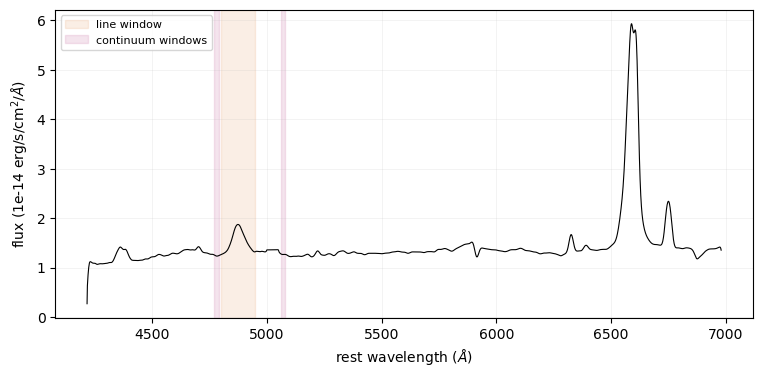

In [3]:
# ---------------- load + quick look: check the windows ----------------
import matplotlib.pyplot as plt

wave, flux, err = read_spec(SPEC)
flux = flux / UNIT

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(wave, flux, color=C_DATA, lw=0.8)
ax.axvspan(*LINE_WIN, color=C_SUB, alpha=0.10, label='line window')
if CONTI_LEFT is not None:
    ax.axvspan(*CONTI_LEFT, color=C_CON, alpha=0.20, label='continuum windows')
    ax.axvspan(*CONTI_RIGHT, color=C_CON, alpha=0.20)
ax.set_xlabel('rest wavelength ($\\AA$)')
ax.set_ylabel('flux (%.0e erg/s/cm$^2$/$\\AA$)' % UNIT)
ax.legend(fontsize=8)
ax.grid(alpha=0.2, lw=0.5)
plt.show()


In [4]:
# ---------------- direct measurement ----------------
r = measure_widths(wave, flux, P)
if r['boundary']:
    print('WARNING: half-max search hit the line window boundary -- '
          'widen LINE_WIN')

print('peak(s)           : ' + ', '.join('%.2f' % x for x in set(r['peaks'])))
print('half-max blue/red : %.2f / %.2f' % (r['lam_blue'], r['lam_red']))
print('centroid lam0     : %.2f' % r['lam0'])
print('FWHM              : %.2f A = %.0f km/s' % (r['fwhm_A'], r['fwhm_kms']))
print('sigma_line        : %.2f A = %.0f km/s' % (r['sigma_A'],
                                                  r['sigma_kms']))
print('FWHM/sigma        : %.3f  (Gaussian: 2.355)'
      % (r['fwhm_kms'] / r['sigma_kms']))


peak(s)           : 4873.89
half-max blue/red : 4846.54 / 4908.99
centroid lam0     : 4878.61
FWHM              : 62.45 A = 3837 km/s
sigma_line        : 28.08 A = 1725 km/s
FWHM/sigma        : 2.224  (Gaussian: 2.355)


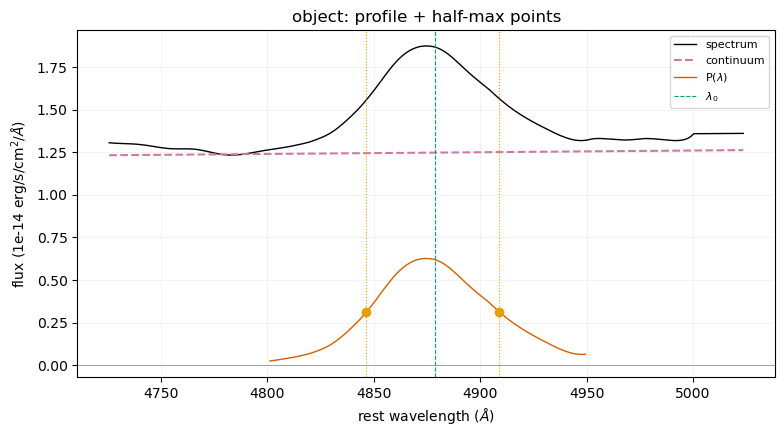

In [5]:
# ---------------- profile + half-max construction plot ----------------
fig, ax = plt.subplots(figsize=(9, 4.5))
lo, hi = LINE_WIN
pad = 0.5 * (hi - lo)
idx = np.where((wave >= lo - pad) & (wave <= hi + pad))[0]
ax.plot(wave[idx], flux[idx], color=C_DATA, lw=1.0, label='spectrum')
ax.plot(wave[idx], r['fcon'][idx], '--', color=C_CON, label='continuum')
ax.plot(r['wave_win'], r['prof_win'], color=C_SUB, lw=1.0,
        label='P($\\lambda$)')
for lam, pk in zip((r['lam_blue'], r['lam_red']), r['peaks']):
    half = 0.5 * r['prof_win'][np.argmin(np.abs(r['wave_win'] - pk))]
    ax.plot(lam, half, 'o', color=C_MODEL, ms=6, zorder=5)
ax.axvline(r['lam_blue'], color=C_MODEL, lw=0.8, ls=':')
ax.axvline(r['lam_red'], color=C_MODEL, lw=0.8, ls=':')
ax.axvline(r['lam0'], color=C_NARROW, lw=0.8, ls='--', label='$\\lambda_0$')
ax.axhline(0.0, color='gray', lw=0.5)
ax.set_xlabel('rest wavelength ($\\AA$)')
ax.set_ylabel('flux (%.0e erg/s/cm$^2$/$\\AA$)' % UNIT)
ax.set_title('%s: profile + half-max points' % OBJ)
ax.legend(fontsize=8)
ax.grid(alpha=0.2, lw=0.5)
plt.show()


In [6]:
# ---------------- bootstrap uncertainties ----------------
bt = bootstrap(wave, flux, P, NBOOT, SEED, keep_duplicates=KEEP_DUPLICATES)
if bt['nfail']:
    print('failed realizations : %d / %d' % (bt['nfail'], NBOOT))
print('FWHM       : %.0f +/- %.0f km/s' % bt['fwhm_kms'])
print('sigma_line : %.0f +/- %.0f km/s' % bt['sigma_kms'])


FWHM       : 3840 +/- 10 km/s
sigma_line : 1718 +/- 12 km/s


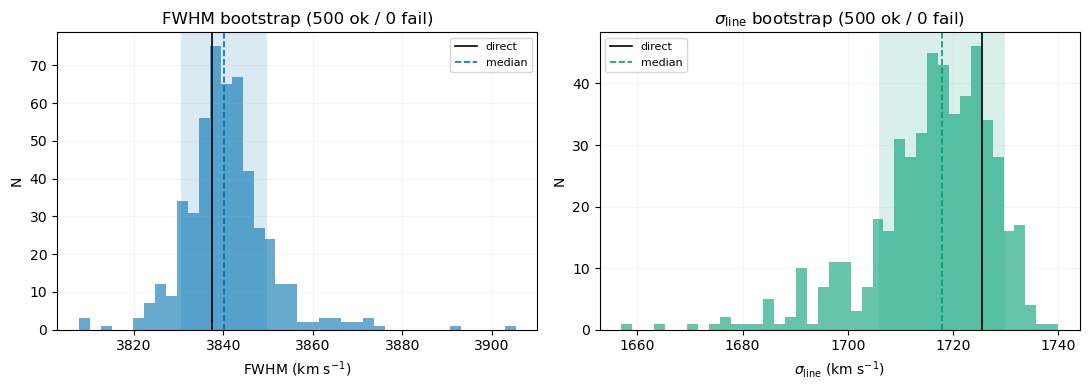

In [7]:
# ---------------- bootstrap histograms ----------------
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, key, color, label in (
        (axes[0], 'fwhm_kms', C_BROAD, 'FWHM'),
        (axes[1], 'sigma_kms', C_NARROW, '$\\sigma_{\\rm line}$')):
    samp = bt['samp_' + key]
    if samp.size:
        ax.hist(samp, bins=40, color=color, alpha=0.6)
    med, std = bt[key]
    ax.axvline(r[key], color=C_DATA, lw=1.2, label='direct')
    ax.axvline(med, color=color, lw=1.2, ls='--', label='median')
    ax.axvspan(med - std, med + std, color=color, alpha=0.15, lw=0)
    ax.set_xlabel('%s (km s$^{-1}$)' % label)
    ax.set_ylabel('N')
    ax.set_title('%s bootstrap (%d ok / %d fail)'
                 % (label, bt['nok'], bt['nfail']))
    ax.legend(fontsize=8)
    ax.grid(alpha=0.2, lw=0.5)
plt.tight_layout()
plt.show()


In [8]:
# ---------------- instrumental broadening + summary ----------------
if LSF_KMS > 0.0:
    print('LSF removed in quadrature: %.0f km/s' % LSF_KMS)
    for key, tag in (('fwhm_kms', 'FWHM'), ('sigma_kms', 'sigma_line')):
        true, terr = subtract_lsf(bt[key][0], bt[key][1], LSF_KMS)
        print('%-22s : %.0f +/- %.0f km/s' % (tag + ' (corrected)',
                                              true, terr))


LSF removed in quadrature: 925 km/s
FWHM (corrected)       : 3727 +/- 10 km/s
sigma_line (corrected) : 1448 +/- 14 km/s


In [ ]:
# ---------------- write outputs (same format as the CLI) ----------------
lines = ['# %s  line %.1f-%.1f  boot %d  seed %d'
         % (OBJ, LINE_WIN[0], LINE_WIN[1], NBOOT, SEED),
         '# quantity        direct      boot_median  boot_std',
         'fwhm_A       %12.4f %12.4f %12.4f'
         % (r['fwhm_A'], bt['fwhm_A'][0], bt['fwhm_A'][1]),
         'sigma_A      %12.4f %12.4f %12.4f'
         % (r['sigma_A'], bt['sigma_A'][0], bt['sigma_A'][1]),
         'lam0_A       %12.4f %12.4f %12.4f'
         % (r['lam0'], bt['lam0'][0], bt['lam0'][1]),
         'fwhm_kms     %12.2f %12.2f %12.2f'
         % (r['fwhm_kms'], bt['fwhm_kms'][0], bt['fwhm_kms'][1]),
         'sigma_kms    %12.2f %12.2f %12.2f'
         % (r['sigma_kms'], bt['sigma_kms'][0], bt['sigma_kms'][1])]
if LSF_KMS > 0.0:
    for key in ('fwhm_kms', 'sigma_kms'):
        true, terr = subtract_lsf(bt[key][0], bt[key][1], LSF_KMS)
        lines.append('%s_corr %12.2f %12.2f   # lsf %.0f km/s'
                     % (key.replace('_kms', ''), true, terr, LSF_KMS))

with open('%s_linewidth.txt' % OBJ, 'w') as f:
    f.write('\n'.join(lines) + '\n')
np.savetxt('%s_linewidth_boot.txt' % OBJ,
           np.column_stack([bt['samp_fwhm_kms'], bt['samp_sigma_kms'],
                            bt['samp_lam0']]),
           fmt='%12.4f', header='fwhm_kms  sigma_kms  lam0_A')
print('wrote %s_linewidth.txt, %s_linewidth_boot.txt' % (OBJ, OBJ))
